# Task 3.2 — Failure Case Experiment

**Paper:** *Analysis of SVM with Indefinite Kernels* (NIPS 2009)

---

This notebook demonstrates a failure case of the proposed method: **very noisy kernel matrices**.

**Hypothesis:** When the noise level added to the kernel matrix is very high, the PSD projection removes most meaningful structure, and the SVM classifier degrades to near-random performance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.linalg import eigh

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ===== Helper functions (from task_2_2) =====

def rbf_kernel(X, Y=None, gamma=0.5):
    if Y is None: Y = X
    sq_X = np.sum(X**2, axis=1).reshape(-1, 1)
    sq_Y = np.sum(Y**2, axis=1).reshape(1, -1)
    dist_sq = np.maximum(sq_X + sq_Y - 2*X@Y.T, 0)
    return np.exp(-gamma * dist_sq)

def make_indefinite_kernel(K, noise_level=0.3, seed=42):
    rng = np.random.RandomState(seed)
    R = rng.randn(K.shape[0], K.shape[0])
    N = (R + R.T) / 2.0
    return K + noise_level * N

def project_to_psd(K):
    eigenvalues, Q = eigh(K)
    eigenvalues_clipped = np.maximum(eigenvalues, 0)
    K_psd = Q @ np.diag(eigenvalues_clipped) @ Q.T
    return (K_psd + K_psd.T) / 2.0

def train_and_evaluate(K_train, y_train, K_test_cross, y_test, C=1.0, max_iter=2000, tol=1e-6):
    """Train SVM and return test accuracy."""
    n = len(y_train)
    Y = np.outer(y_train, y_train)
    K_tilde = Y * K_train
    
    eig_vals = np.linalg.eigvalsh(K_tilde)
    L = np.max(np.abs(eig_vals))
    if L < 1e-10: L = 1.0
    
    alpha = np.zeros(n)
    for t in range(max_iter):
        grad = -np.ones(n) + K_tilde @ alpha
        alpha_new = np.clip(alpha - (1/L) * grad, 0, C)
        if np.linalg.norm(alpha_new - alpha) < tol: break
        alpha = alpha_new
    
    free_sv = (alpha > 1e-5) & (alpha < C - 1e-5)
    b = np.mean(y_train[free_sv] - (alpha * y_train) @ K_train[free_sv].T) if np.sum(free_sv) > 0 else 0
    
    decision = (alpha * y_train) @ K_test_cross + b
    preds = np.sign(decision)
    preds[preds == 0] = 1
    
    return accuracy_score(y_test, preds)

print('Helper functions defined.')

Helper functions defined.


In [3]:
# Load and preprocess dataset
iris = load_iris()
mask = iris.target >= 1
X = iris.data[mask]
y = np.where(iris.target[mask] == 1, -1, 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

gamma = 0.5
K_psd_train = rbf_kernel(X_train, gamma=gamma)
K_psd_test = rbf_kernel(X_train, X_test, gamma=gamma)

print(f'Dataset: {X_train.shape[0]} train, {X_test.shape[0]} test')

Dataset: 80 train, 20 test


---

## Experiment: Accuracy vs. Noise Level

We sweep the noise level $\sigma$ from 0 (no noise, PSD kernel) to very high values and measure how accuracy degrades.

In [4]:
# Sweep noise levels
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 10.0]
accuracies = []
n_negative_eigs = []

print('Noise Level | Accuracy | Negative Eigenvalues')
print('-' * 50)

for sigma in noise_levels:
    if sigma == 0:
        K_train_used = K_psd_train.copy()
    else:
        K_indef = make_indefinite_kernel(K_psd_train, noise_level=sigma)
        K_train_used = project_to_psd(K_indef)
    
    # Count negative eigenvalues of indefinite kernel (before projection)
    if sigma > 0:
        eig_indef = np.linalg.eigvalsh(K_indef)
        n_neg = np.sum(eig_indef < 0)
    else:
        n_neg = 0
    n_negative_eigs.append(n_neg)
    
    acc = train_and_evaluate(K_train_used, y_train, K_psd_test, y_test)
    accuracies.append(acc)
    print(f'  {sigma:6.2f}     |  {acc:.4f}  |  {n_neg}')

print(f'\nBaseline (no noise): {accuracies[0]:.4f}')
print(f'Worst case (σ={noise_levels[-1]}): {accuracies[-1]:.4f}')

Noise Level | Accuracy | Negative Eigenvalues
--------------------------------------------------
    0.00     |  0.8500  |  0
    0.05     |  0.8000  |  25
    0.10     |  0.8000  |  29
    0.20     |  0.8000  |  32
    0.30     |  0.8000  |  34
    0.50     |  0.8000  |  36
    0.80     |  0.8000  |  39
    1.00     |  0.8000  |  39
    1.50     |  0.8500  |  39
    2.00     |  0.8000  |  40
    3.00     |  0.8000  |  40
    5.00     |  0.8500  |  40
    8.00     |  0.8500  |  41
   10.00     |  0.8500  |  41

Baseline (no noise): 0.8500
Worst case (σ=10.0): 0.8500


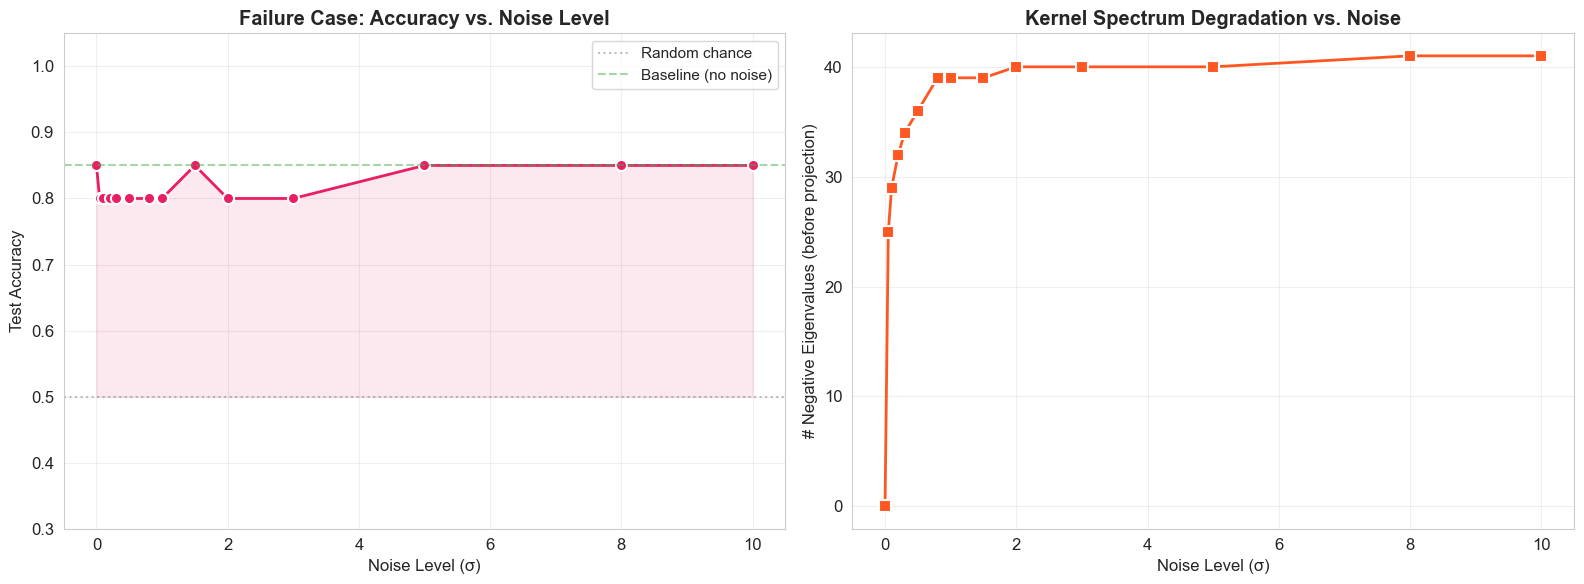

Saved: results/failure_case_noise.png


In [5]:
# Plot: Accuracy vs Noise Level
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy vs noise
axes[0].plot(noise_levels, accuracies, 'o-', color='#E91E63', 
             linewidth=2, markersize=8, markeredgecolor='white', markeredgewidth=1.5)
axes[0].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random chance')
axes[0].axhline(y=accuracies[0], color='#4CAF50', linestyle='--', alpha=0.5, label='Baseline (no noise)')
axes[0].fill_between(noise_levels, 0.5, accuracies, alpha=0.1, color='#E91E63')

axes[0].set_xlabel('Noise Level (σ)', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Failure Case: Accuracy vs. Noise Level', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_ylim(0.3, 1.05)
axes[0].grid(True, alpha=0.3)

# Number of negative eigenvalues vs noise
axes[1].plot(noise_levels, n_negative_eigs, 's-', color='#FF5722', 
             linewidth=2, markersize=8, markeredgecolor='white', markeredgewidth=1.5)
axes[1].set_xlabel('Noise Level (σ)', fontsize=12)
axes[1].set_ylabel('# Negative Eigenvalues (before projection)', fontsize=12)
axes[1].set_title('Kernel Spectrum Degradation vs. Noise', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/failure_case_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/failure_case_noise.png')

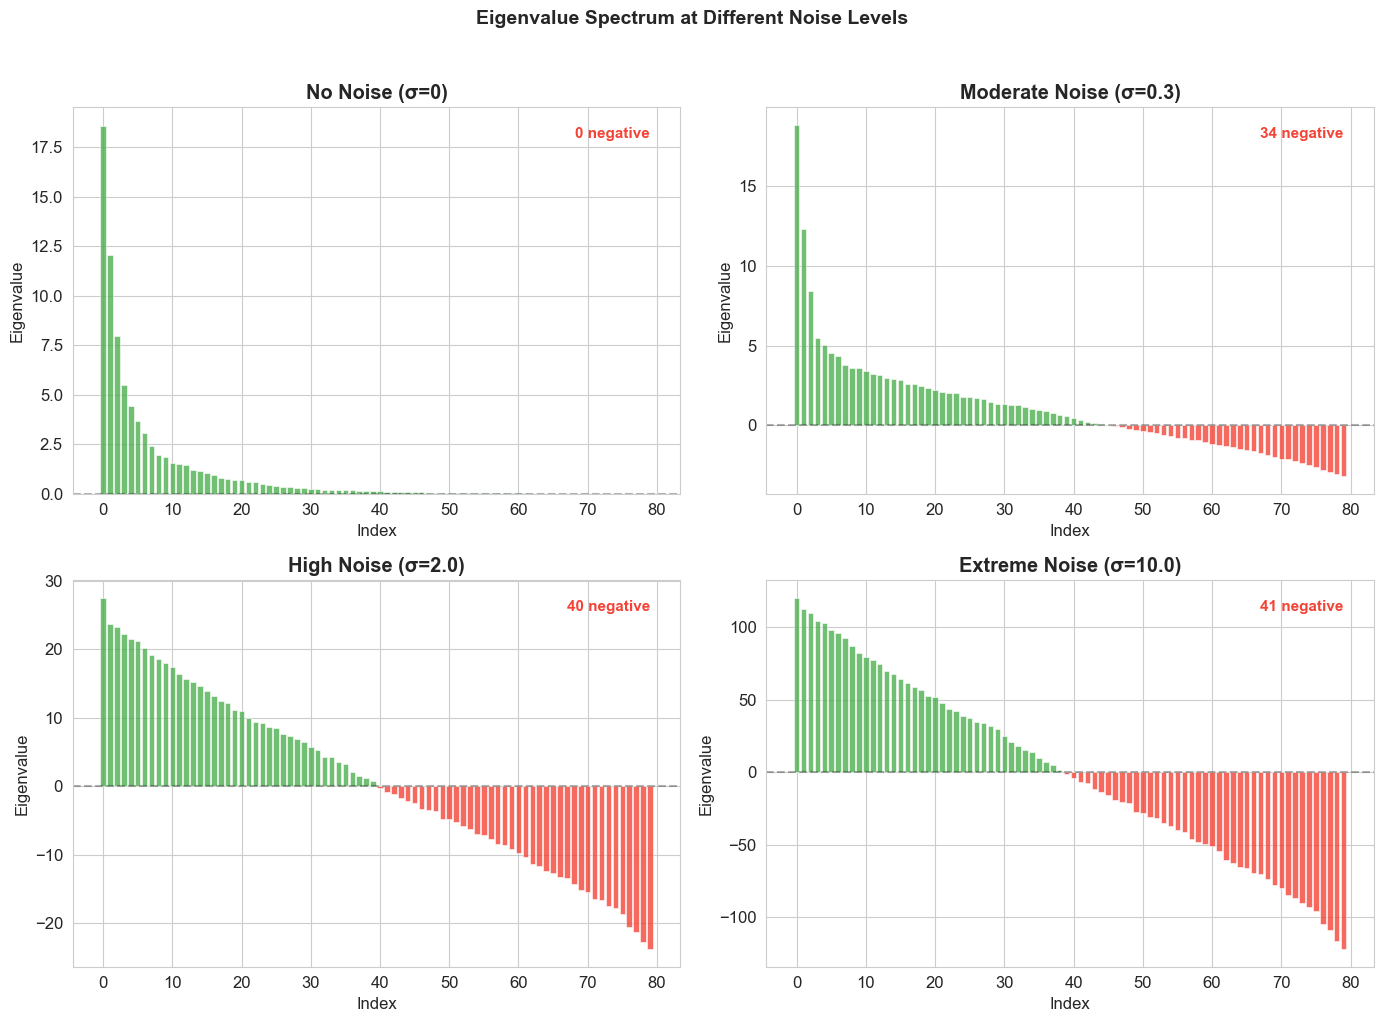

Saved: results/failure_eigenvalue_spectrum.png


In [6]:
# Eigenvalue spectrum at different noise levels
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
noise_showcase = [0.0, 0.3, 2.0, 10.0]
titles = ['No Noise (σ=0)', 'Moderate Noise (σ=0.3)', 'High Noise (σ=2.0)', 'Extreme Noise (σ=10.0)']

for idx, (sigma, title) in enumerate(zip(noise_showcase, titles)):
    ax = axes[idx // 2, idx % 2]
    if sigma == 0:
        eigs = np.sort(np.linalg.eigvalsh(K_psd_train))[::-1]
        colors = ['#4CAF50'] * len(eigs)
    else:
        K_noisy = make_indefinite_kernel(K_psd_train, noise_level=sigma)
        eigs = np.sort(np.linalg.eigvalsh(K_noisy))[::-1]
        colors = ['#F44336' if v < 0 else '#4CAF50' for v in eigs]
    
    ax.bar(range(len(eigs)), eigs, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Index')
    ax.set_ylabel('Eigenvalue')
    n_neg = np.sum(np.array(eigs) < 0)
    ax.text(0.95, 0.95, f'{n_neg} negative', transform=ax.transAxes, 
            ha='right', va='top', fontsize=11, color='#F44336', fontweight='bold')

plt.suptitle('Eigenvalue Spectrum at Different Noise Levels', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/failure_eigenvalue_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/failure_eigenvalue_spectrum.png')

---

## Analysis: Why the Method Fails

### Root Cause

The method fails under extreme noise because:

1. **Signal-to-Noise Ratio (SNR) collapse:** When $\sigma$ is very large, the noise matrix $N$ dominates the original kernel $K$. The eigenvalue spectrum becomes dominated by random noise eigenvalues, following the Wigner semicircle distribution.

2. **PSD projection loses information:** With extreme noise, a large proportion of eigenvalues become negative and are clipped to zero. This removes both noise AND signal information. The projected kernel $K_{+}$ retains little discriminative structure.

3. **Effective kernel becomes trivial:** At very high noise levels, the PSD-projected kernel approaches a low-rank or near-zero matrix, providing no useful similarity information for classification.

### Mathematical Explanation

The Frobenius norm of the noise $\|\sigma N\|_F \propto \sigma \cdot n$, while the signal $\|K\|_F \propto n$ remains fixed. When $\sigma \gg 1$, the noise overwhelms the signal:

$$\text{SNR} = \frac{\|K\|_F}{\|\sigma N\|_F} \propto \frac{1}{\sigma} \to 0$$

### Practical Implications

This failure mode suggests that the method from the paper works best when:
- The indefiniteness is **moderate** (a small number of negative eigenvalues)
- The **positive eigenspace** preserves the discriminative structure
- The kernel matrix has a reasonable **signal-to-noise ratio**

For extremely noisy or heavily indefinite kernels, alternative approaches may be needed, such as:
- Robust kernel learning methods
- Kernel denoising before PSD projection
- Non-metric embedding methods